In [5]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from langchain_groq import ChatGroq

In [2]:
load_dotenv()

True

In [3]:
class ParentState(TypedDict):

    question: str
    answer_eng: str
    answer_hin: str
    

In [6]:
parent_llm = ChatGroq(
    model="openai/gpt-oss-120b",
    temperature=0.1)
subgraph_llm = ChatGroq(
    model="openai/gpt-oss-120b",
    temperature=0.3)

In [7]:
def translate_text(state: ParentState):

    prompt = f"""
Translate the following text to Hindi.
Keep it natural and clear. Do not add extra content.

Text:
{state["answer_eng"]}
""".strip()
    
    translated_text = subgraph_llm.invoke(prompt).content

    return {'answer_hin': translated_text}

In [8]:
subgraph_builder = StateGraph(ParentState)

subgraph_builder.add_node('translate_text', translate_text)

subgraph_builder.add_edge(START, 'translate_text')
subgraph_builder.add_edge('translate_text', END)

subgraph = subgraph_builder.compile()

In [9]:
def generate_answer(state: ParentState):

    answer = parent_llm.invoke(f"You are a helpful assistant. Answer clearly.\n\nQuestion: {state['question']}").content
    return {'answer_eng': answer}

In [ ]:
parent_builder = StateGraph(ParentState)

parent_builder.add_node("answer", generate_answer)
parent_builder.add_node("translate", subgraph) #subgraph as a node

parent_builder.add_edge(START, 'answer')
parent_builder.add_edge('answer', 'translate')
parent_builder.add_edge('translate', END)

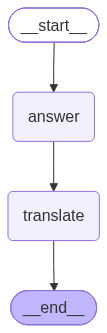

In [11]:
graph = parent_builder.compile()

graph

In [12]:
graph.invoke({'question': 'What is quantum physics'})

{'question': 'What is quantum physics',
 'answer_eng': '**Quantum physics** (also called quantum mechanics or quantum theory) is the branch of physics that describes how matter and energy behave at the smallest scales—typically at the level of atoms, electrons, photons, and other sub‑atomic particles.  \n\n---\n\n### Core Ideas\n\n| Concept | What it means | Why it matters |\n|---------|---------------|----------------|\n| **Quantization** | Certain physical quantities (energy, angular momentum, charge) can only take on discrete values, not a continuous range. | Explains why atoms emit/absorb light at specific wavelengths (spectral lines). |\n| **Wave‑Particle Duality** | Particles such as electrons and photons exhibit both wave‑like (interference, diffraction) and particle‑like (localized impacts) behavior. | Leads to phenomena like the double‑slit experiment, where a single particle creates an interference pattern. |\n| **Superposition** | A quantum system can exist in a combination 